# Evaluación detallada del modelo

Equivalente explicado de `evaluar_modelo.py`. Debe ejecutarse después del entrenamiento porque carga `pipeline_adult_income.pkl`. No vuelve a ajustar el modelo ni redefine el feature engineering.

In [6]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from src.config import FIGURES_DIR, MODEL_DIR, OUTPUT_DIR, RANDOM_STATE, TEST_SIZE
from src.data import load_adult, split_features_target
from src.quality import run_quality_gates

## 1. Reconstruir el mismo holdout
La misma semilla, tamaño y estratificación reproducen el conjunto de prueba usado durante entrenamiento. Los gates vuelven a validar el contrato de los datos.

In [2]:
df = load_adult()
run_quality_gates(df)
X, y = split_features_target(df)
_, X_test, _, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
X_test.shape

(9769, 14)

## 2. Cargar el pipeline persistido
El objeto incluye preprocesamiento y modelo. `predict` y `predict_proba` aceptan las columnas originales.

In [7]:
model_path = MODEL_DIR / 'pipeline_adult_income.pkl'
if not model_path.exists():
    raise FileNotFoundError('Primero ejecute Pipeline_adult.py o 03_pipeline_adult.ipynb')
pipeline = joblib.load(model_path)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

## 3. Matriz de confusión
Muestra verdaderos y falsos positivos/negativos. Permite detectar si el modelo favorece la clase mayoritaria aunque el accuracy sea alto.

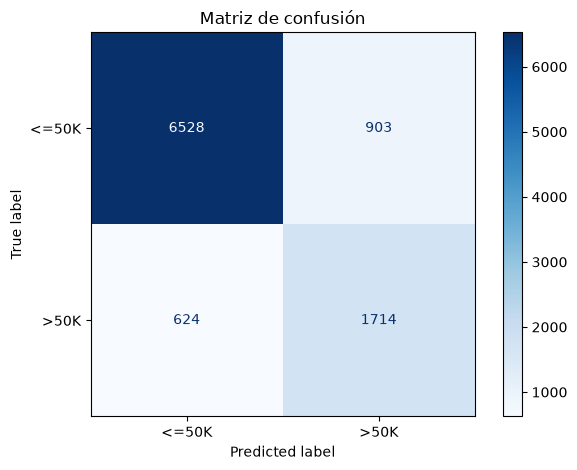

In [8]:
ConfusionMatrixDisplay.from_estimator(
    pipeline, X_test, y_test, display_labels=['<=50K', '>50K'], cmap='Blues'
)
plt.title('Matriz de confusión')
plt.tight_layout()
plt.show()

## 4. ROC-AUC
ROC-AUC evalúa la capacidad de ordenar positivos por encima de negativos en todos los umbrales. Un valor cercano a 1 indica buena separación; 0.5 equivale a azar.

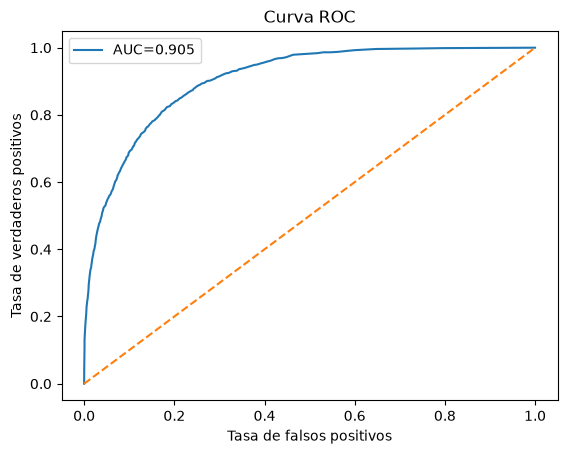

In [9]:
probabilities = pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, probabilities)
fpr, tpr, _ = roc_curve(y_test, probabilities)
plt.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

## 5. Precision-Recall
Esta curva es especialmente informativa cuando la clase positiva es minoritaria. Average Precision resume el compromiso entre recuperar positivos y evitar falsas alarmas.

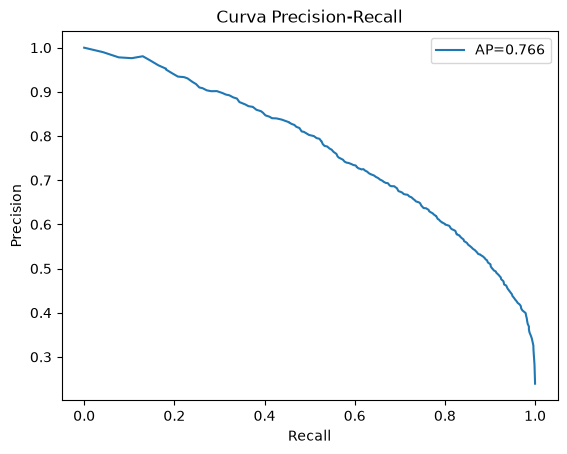

In [10]:
precision, recall, _ = precision_recall_curve(y_test, probabilities)
average_precision = average_precision_score(y_test, probabilities)
plt.plot(recall, precision, label=f'AP={average_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.show()

## 6. Guardar métricas de probabilidad
Estas métricas complementan las obtenidas con el umbral de clasificación por defecto.

In [11]:
probability_metrics = pd.DataFrame([{
    'roc_auc': roc_auc,
    'average_precision': average_precision,
}])
probability_metrics.to_csv(OUTPUT_DIR / 'metricas_probabilidad.csv', index=False)
probability_metrics

,roc_auc,average_precision
0,0.904947,0.765725


## Decisión de evaluación
No se selecciona un modelo usando solo accuracy. F1, ROC-AUC, Average Precision y la matriz de confusión permiten evaluar el desempeño sobre la clase >50K y elegir posteriormente un umbral según el costo de falsos positivos y falsos negativos.